# PetroRAG — Exploração de Embeddings

Demonstra as capacidades do pipeline de busca semântica:
- Representação multilíngue (PT-BR / EN) via sentence-transformers
- Similaridade semântica por cosseno entre termos do domínio offshore
- Visualização t-SNE dos embeddings de chunks do dataset 3W
- Busca semântica sobre o índice FAISS

**Primeira execução:** rode a célula de instalação, reinicie o kernel (`Kernel > Restart Kernel`),
depois execute a partir da célula de setup.

In [1]:
# ---------------------------------------------------------------------------
# Instalação de dependências no ambiente Python deste kernel.
# Executar uma vez; reiniciar o kernel após a conclusão.
# ---------------------------------------------------------------------------
import sys
import subprocess

PACKAGES = [
    'sentence-transformers',
    'scikit-learn',
    'langchain',
    'langchain-core',
    'langchain-community',
    'langchain-huggingface',
    'langchain-text-splitters',
    'faiss-cpu',
    'pypdf',
    'python-dotenv',
]

for pkg in PACKAGES:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '--quiet'],
        capture_output=True,
        text=True,
    )
    status = 'OK' if result.returncode == 0 else 'FAILED'
    print(f'[{status}] {pkg}')
    if result.returncode != 0:
        print(f'       {result.stderr.strip()[:300]}')

print('\nInstallation complete. Restart the kernel before proceeding.')

[OK] sentence-transformers
[OK] scikit-learn
[OK] langchain
[OK] langchain-core
[OK] langchain-community
[OK] langchain-huggingface
[OK] langchain-text-splitters
[OK] faiss-cpu
[OK] pypdf
[OK] python-dotenv

Installation complete. Restart the kernel before proceeding.


In [1]:
# ---------------------------------------------------------------------------
# autoreload: recarrega automaticamente módulos src/ alterados em disco
# antes de cada célula, eliminando a necessidade de reiniciar o kernel
# durante o desenvolvimento.
# ---------------------------------------------------------------------------
%load_ext autoreload
%autoreload 2

# Suprime o conflito Intel/LLVM OpenMP em ambientes Anaconda no Windows.
# Deve ser definido antes de qualquer import que carregue numpy ou torch.
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
sys.path.insert(0, '..')

# Dependency check
REQUIRED_MODULES = ['sentence_transformers', 'sklearn', 'faiss', 'langchain_core']
missing = []
for mod in REQUIRED_MODULES:
    try:
        __import__(mod)
        print(f'[OK]     {mod}')
    except ImportError:
        missing.append(mod)
        print(f'[MISSING] {mod}')

if missing:
    raise ImportError(
        f'Modules not found: {missing}. '
        'Run the installation cell and restart the kernel.'
    )

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from config import EMBEDDING_MODEL, RAW_DIR
from src.indexer import load_documents, split_documents, build_index
from src.retriever import semantic_search

print(f'\nEmbedding model : {EMBEDDING_MODEL}')
print(f'Data directory  : {RAW_DIR}')

[OK]     sentence_transformers
[OK]     sklearn
[OK]     faiss
[OK]     langchain_core

Embedding model : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Data directory  : D:\Alan\Alan\Pos GRADUAÇÂO USP\eEDB-007 - Trabalho de Conclusão\projeto-3w-aws\nlp-petroleo-rag\data\raw


## 1. Carregar modelo de embeddings

Na primeira execução o modelo (~120 MB) é baixado automaticamente do HuggingFace Hub.

In [ ]:
model = SentenceTransformer(EMBEDDING_MODEL)
print(f'Model  : {EMBEDDING_MODEL}')
print(f'Max seq: {model.max_seq_length} tokens')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model  : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Max seq: 128 tokens


## 2. Matriz de similaridade semântica (PT-BR <-> EN)

Demonstra que o modelo multilíngue captura equivalência semântica entre termos em
português e inglês sem tradução explícita. Pares equivalentes devem apresentar
alta similaridade (blocos 2x2 na diagonal).

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

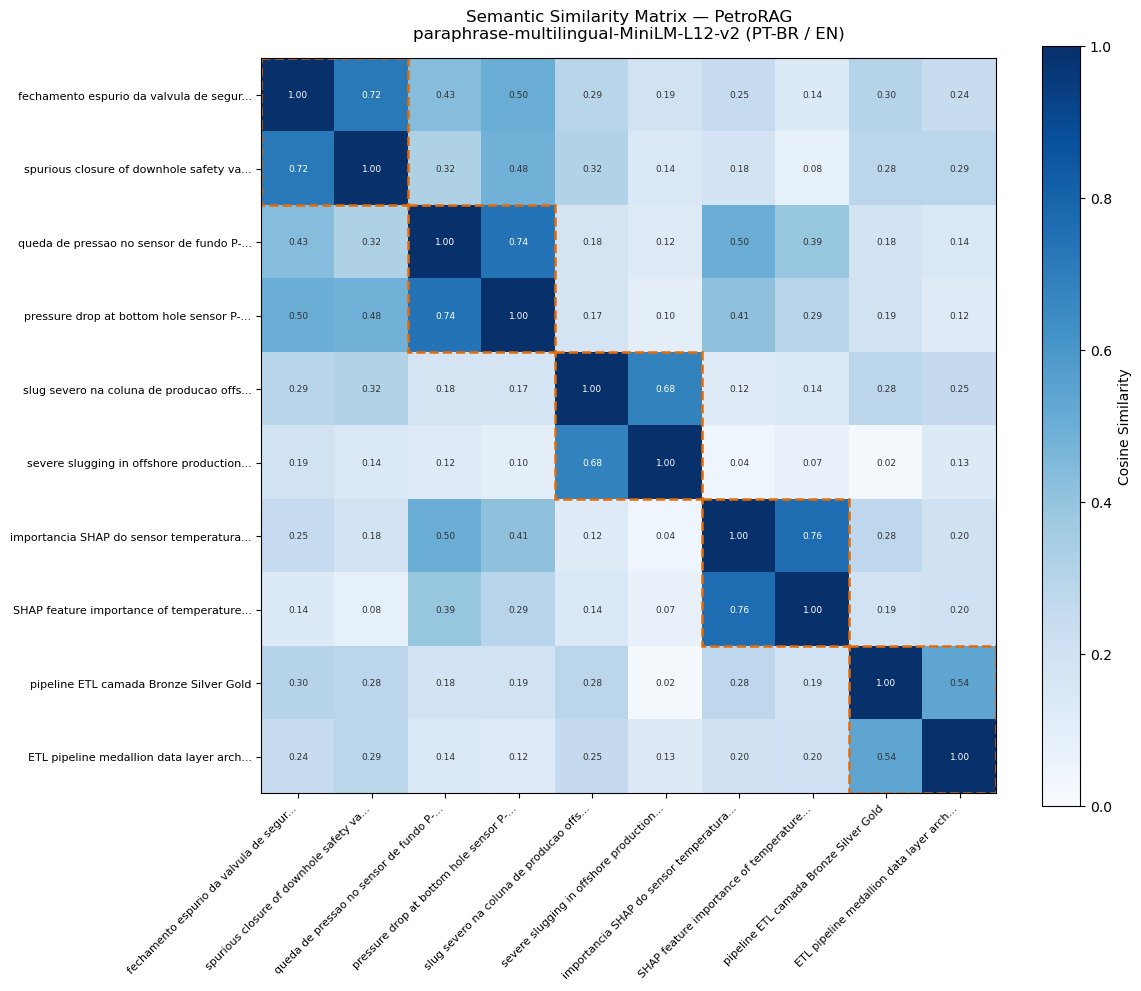

Saved: assets/similarity_matrix.png


In [ ]:
TERM_PAIRS = [
    ('fechamento espurio da valvula de seguranca DHSV',  'spurious closure of downhole safety valve'),
    ('queda de pressao no sensor de fundo P-PDG',        'pressure drop at bottom hole sensor P-PDG'),
    ('slug severo na coluna de producao offshore',       'severe slugging in offshore production riser'),
    ('importancia SHAP do sensor temperatura T-JUS-CKP', 'SHAP feature importance of temperature sensor'),
    ('pipeline ETL camada Bronze Silver Gold',           'ETL pipeline medallion data layer architecture'),
]

terms  = [t for pair in TERM_PAIRS for t in pair]
labels = [t[:38] + '...' if len(t) > 38 else t for t in terms]

embeddings = model.encode(terms, normalize_embeddings=True, show_progress_bar=True)
sim_matrix = cosine_similarity(embeddings)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(sim_matrix, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_xticks(range(len(terms)))
ax.set_yticks(range(len(terms)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(terms)):
    for j in range(len(terms)):
        color = 'white' if sim_matrix[i, j] > 0.6 else '#333333'
        ax.text(j, i, f'{sim_matrix[i, j]:.2f}',
                ha='center', va='center', fontsize=6.5, color=color)

for k in range(len(TERM_PAIRS)):
    rect = plt.Rectangle((2*k - 0.5, 2*k - 0.5), 2, 2,
                          fill=False, edgecolor='#E36C09', linewidth=1.8, linestyle='--')
    ax.add_patch(rect)

ax.set_title(
    'Semantic Similarity Matrix — PetroRAG\n'
    'paraphrase-multilingual-MiniLM-L12-v2 (PT-BR / EN)',
    fontsize=12, pad=14
)
plt.tight_layout()
plt.savefig('../assets/similarity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/similarity_matrix.png')

## 3. t-SNE — distribuição dos embeddings por chunks

Redução para 2D via t-SNE para inspecionar a separação semântica entre fragmentos
do documento de amostra.

100%|██████████| 1/1 [00:00<00:00, 683.56it/s]

Documents loaded : 40
Chunks generated : 164


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

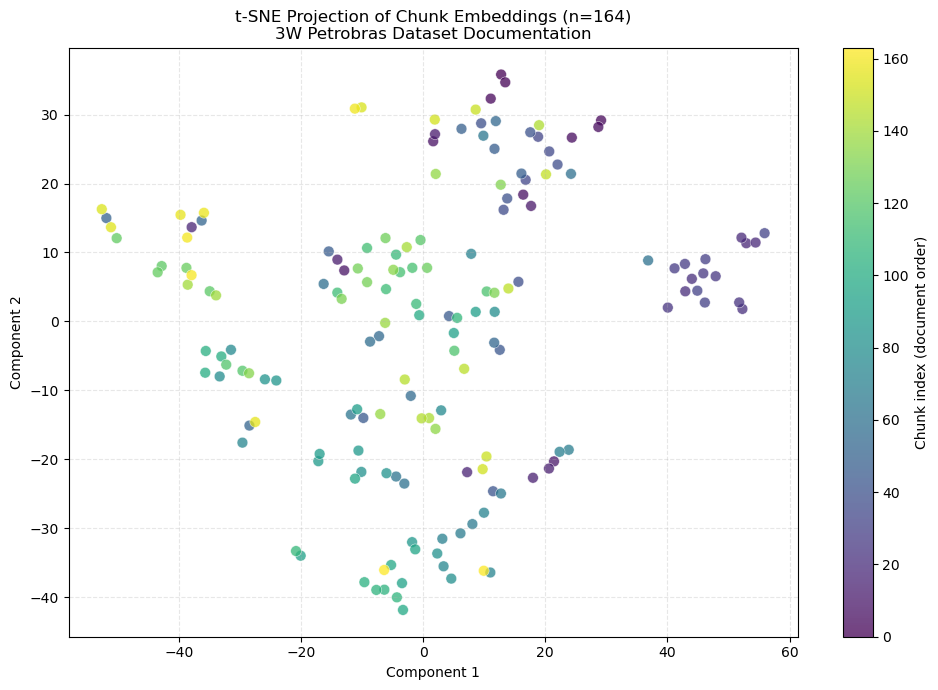

Saved: assets/tsne_embeddings.png


In [ ]:
docs   = load_documents(RAW_DIR)
chunks = split_documents(docs)
print(f'Documents loaded : {len(docs)}')
print(f'Chunks generated : {len(chunks)}')

texts            = [c.page_content for c in chunks]
chunk_embeddings = model.encode(texts, normalize_embeddings=True, show_progress_bar=True)

perplexity = min(5, len(texts) - 1)
tsne       = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
coords     = tsne.fit_transform(chunk_embeddings)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=range(len(texts)), cmap='viridis',
    alpha=0.75, s=60, edgecolors='white', linewidths=0.4,
)
plt.colorbar(sc, ax=ax, label='Chunk index (document order)')
ax.set_title(
    f't-SNE Projection of Chunk Embeddings (n={len(texts)})\n'
    '3W Petrobras Dataset Documentation',
    fontsize=12
)
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../assets/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/tsne_embeddings.png')

## 4. Busca semântica — exemplos de queries em PT-BR

In [ ]:
vectorstore = build_index()

QUERIES = [
    'Qual sensor tem maior importancia para detectar fechamento da DHSV?',
    'Como o pipeline processa dados faltantes nos sensores?',
    'Quais sao as classes de eventos do dataset 3W?',
    'Fale pra min algo sobre extração de petróleo?',
    'O que a analise de SHAP revela sobre a importancia dos sensores de temperatura e pressao?',
    'Qual poço apresenta informação com todos os sensores?',
]

for query in QUERIES:
    print(f'\nQuery: {query}')
    print('-' * 65)
    results = semantic_search(vectorstore, query, k=2)
    for rank, result in enumerate(results, start=1):
        similarity_pct = (1 / (1 + result.score)) * 100
        snippet = result.content[:220].replace('\n', ' ')
        print(f'  [{rank}] sim={similarity_pct:.1f}%  {snippet}...')